# High-z Example 12: Stellar Mass Distribution

**EPS Research — High-z Kinematic Corpus Z1**

Stellar masses from ALPINE SED fitting (Faisst et al. 2020).
log M* range: ~9-11 Msun — consistent with massive star-forming
main-sequence galaxies at the peak of cosmic star formation.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369286  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/21327061/files/high_z_kinematic_corpus_Z1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt

rows = []
with open('high_z_kinematic_corpus_Z1_flat.csv') as f:
    for r in csv.DictReader(f):
        rows.append(r)
print(f"Total galaxies: {len(rows)}")


Total galaxies: 31


Galaxies with M*: 31
log M* range: 9.70 -- 10.60
Median log M*: 10.10


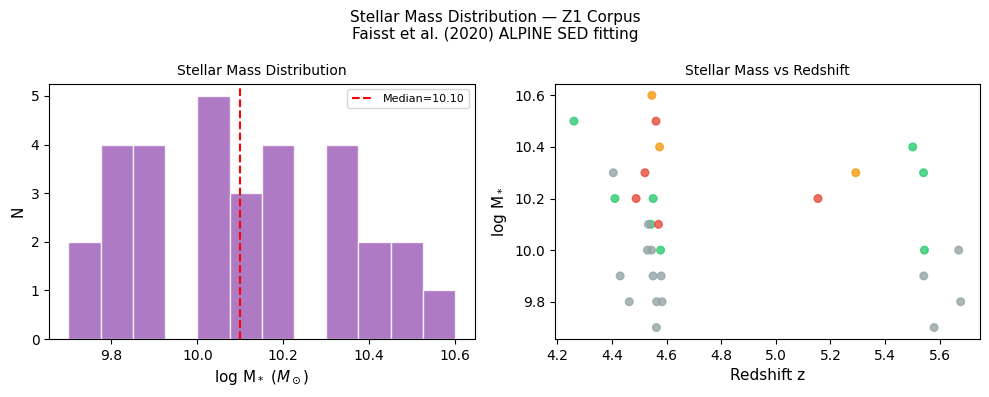

In [3]:
import numpy as np
data = [(r['galaxy'], float(r['log_mstar_msun']), r['class_jones2021'])
        for r in rows if r.get('log_mstar_msun')]
log_ms = [d[1] for d in data]
print(f"Galaxies with M*: {len(data)}")
print(f"log M* range: {min(log_ms):.2f} -- {max(log_ms):.2f}")
print(f"Median log M*: {np.median(log_ms):.2f}")

COLORS = {'ROT':'#2ecc71','MER':'#e74c3c','DIS':'#f39c12','UNC':'#95a5a6'}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(log_ms, bins=12, color='#9b59b6', alpha=0.8, edgecolor='white')
axes[0].axvline(np.median(log_ms), color='red', ls='--', lw=1.5,
                label=f'Median={np.median(log_ms):.2f}')
axes[0].set_xlabel(r'log M$_*$ ($M_\odot$)', fontsize=11)
axes[0].set_ylabel('N', fontsize=11)
axes[0].set_title('Stellar Mass Distribution', fontsize=10)
axes[0].legend(fontsize=8)

zs = [float(r['redshift']) for r in rows if r.get('log_mstar_msun')]
classes = [r['class_jones2021'] for r in rows if r.get('log_mstar_msun')]
axes[1].scatter(zs, log_ms, s=30,
    c=[COLORS.get(c,'gray') for c in classes], alpha=0.8)
axes[1].set_xlabel('Redshift z', fontsize=11)
axes[1].set_ylabel(r'log M$_*$', fontsize=11)
axes[1].set_title('Stellar Mass vs Redshift', fontsize=10)

plt.suptitle('Stellar Mass Distribution — Z1 Corpus\n'
             'Faisst et al. (2020) ALPINE SED fitting', fontsize=11)
plt.tight_layout()
plt.savefig('hz12_stellar_mass.png', dpi=150, bbox_inches='tight')
plt.show()